In [45]:
import matplotlib
import matplotlib.pyplot as plt
import plotly.graph_objects as go

from src.OrganoidMesh import OrganoidMesh
from src.mesh_analysis import *
from src.nonlocal_correlations import *
from src.cell_graph_functions import *

## Load organoid mesh, extract and filter marker fields

For illustration purposes we just treat a single organoid 

In [46]:
data_dir = '../NicoleData/20250929/fractal_output'

# choose one timepoint/well/round
timepoint = "day4p5"
zarr_name = "r0.zarr"
well = "B06"
round_name = "0_fused_zillum_registered"
organoid_id = 49  # 19 # example

# timepoint = "day4p5"
# zarr_name = "r0.zarr"
# well = "A06"
# round_name = "0_fused_zillum_registered"
# organoid_id = 31 # example

path = f"{data_dir}/{timepoint}/{zarr_name}/{well[0]}/{well[1:]}/{round_name}/meshes/nnorg_linked_multi_annotated_class/{organoid_id}.vtp"


mesh = OrganoidMesh()
mesh.load_mesh_from_file(path)
mesh.align_with_pca()
_ = mesh.compute_spectral_coefficients(lmax=15)    # must populate m.eigvals, m.eigvecs

print(mesh.v.shape)

[Info] Eigen-decomposition not found. Computing now...
(18001, 3)


Extracting the fate marker intensity fields - the binary fields (0/1 indicating whether a cell is positive for a given expression) will be computed after coarse-graining.

In [ ]:
t_hks = np.logspace(0, 2, num=50)
hks, hks_coeffs = compute_hks(mesh, t=t_hks) # HKS at time-scale comparable to cell size

In [48]:
indices = [15750, 9350, 5200]   # villus

# indices = [9350]   # neck
# indices = [5200]   # crypt

arr = np.asarray(hks[:,0]-np.mean(hks[:,0]))
vmax = np.nanmax(np.abs(arr)) - 0.005

fig = go.Figure()

fig.add_trace(
    go.Mesh3d(
        x=mesh.v[:,0], y=mesh.v[:,1], z=mesh.v[:,2],
        i=mesh.f[:,0], j=mesh.f[:,1], k=mesh.f[:,2],
        intensity=hks[:,0]-np.mean(hks[:,0]),
        colorscale='RdBu_r',
        cmin=-vmax,
        cmax=+vmax,
        cmid=0,
    )
)


fig.add_trace(
    go.Scatter3d(
        x=mesh.v[indices,0],
        y=mesh.v[indices,1],
        z=mesh.v[indices,2],
        mode="markers",
        marker=dict(
            size=8,
            color='black',
            line=dict(color='white', width=2)
        ),
        showlegend=False
    )
)

fig.update_layout(
    scene = dict(
        xaxis=dict(visible=False),
        yaxis=dict(visible=False),
        zaxis=dict(visible=False),
        bgcolor='rgba(0,0,0,0)',   # optional, makes background transparent
    )
)



fig.update_layout(height=550, width=750, title='HKS')
fig.show()

# fig.write_image("single_organoid_HKS_highlights.svg")


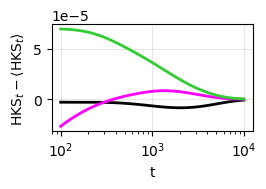

In [49]:
# plt.plot(t_hks, (hks[indices[0], :]-np.mean(hks,axis=0)))
# plt.plot(t_hks, (hks[indices[1], :]-np.mean(hks,axis=0)))
# plt.plot(t_hks, (hks[indices[2], :]-np.mean(hks,axis=0)))

# pick high-contrast colors vs RdBu_r:
colors = ["black", "magenta", "limegreen"]

plt.figure(figsize=(3,2))

for idx, c in zip(indices, colors):
    plt.plot(t_hks, (hks[idx, :]-np.mean(hks,axis=0)),
             color=c,
             linewidth=2,
             label=f"vertex {idx}")

plt.xscale('log')
plt.xlabel("t")
plt.ylabel(r"$\mathrm{HKS}_t - \langle \mathrm{HKS}_t \rangle$")
plt.grid(alpha=0.3)
# plt.legend()
# plt.title("Heat Kernel Signature vs time — selected vertices")

plt.tight_layout()

plt.savefig("hks_vertices.svg", format="svg")

plt.show()


In [ ]:
# ============================================================
# Plot geodesic distance to a specified source vertex + isocurves
# ============================================================

# --- USER SETTINGS ---
source_vertex = 5200          # <-- set this to the vertex index you want (int)
n_isocurves   = 12         # number of iso-levels
iso_min       = None       # e.g. 0.0 (leave None to auto)
iso_max       = None       # e.g. np.nanpercentile(dist, 95) (leave None to auto)
iso_band      = 0.003      # relative band around each level (fraction of (iso_max-iso_min)); controls line thickness

# --- compute geodesic distance on mesh vertices ---
# Assumes you have compute_geodesics(mesh, sources=[...], t=...) available (as in your earlier code)
dist = compute_geodesics(mesh, sources=[int(source_vertex)], t=None)
dist = np.asarray(dist).squeeze()
if dist.ndim != 1 or dist.shape[0] != mesh.v.shape[0]:
    raise ValueError("compute_geodesics returned unexpected shape; expected (V,) for a single source.")

# --- choose isocurve levels ---
dmin = float(np.nanmin(dist)) if iso_min is None else float(iso_min)
dmax = float(np.nanpercentile(dist, 98)) if iso_max is None else float(iso_max)  # robust upper bound
levels = np.linspace(dmin, dmax, n_isocurves + 2)[1:-1]  # exclude endpoints
band = float(iso_band) * max(dmax - dmin, 1e-12)

# ============================================================
# Helper: extract iso-line segments on a triangular mesh
# (marching-triangles style: for each triangle, intersect with level)
# ============================================================
def extract_isoline_segments(v, f, field, level, band=None):
    """
    Return Nx2x3 array of line segments approximating the isoline field=level.
    Uses linear interpolation on triangle edges.
    If band is not None, keeps triangles with min(field) <= level <= max(field) (standard).
    """
    v = np.asarray(v, float)
    f = np.asarray(f, int)
    s = np.asarray(field, float)

    segs = []

    for tri in f:
        ids = tri
        vals = s[ids]
        if not np.all(np.isfinite(vals)):
            continue

        lo, hi = vals.min(), vals.max()
        if level < lo or level > hi:
            continue

        # edges of triangle (a,b)
        edges = [(0,1), (1,2), (2,0)]
        pts = []

        for a, b in edges:
            va, vb = vals[a], vals[b]
            if (va - level) == 0.0 and (vb - level) == 0.0:
                # entire edge lies on contour (rare); skip to avoid heavy overdraw
                continue

            # check if the edge crosses the level (including one endpoint)
            if (va - level) * (vb - level) <= 0:
                if va == vb:
                    continue
                t = (level - va) / (vb - va)
                if 0.0 <= t <= 1.0:
                    pa = v[ids[a]]
                    pb = v[ids[b]]
                    p = pa + t * (pb - pa)
                    pts.append(p)

        # typical case: 2 intersection points => one segment
        if len(pts) == 2:
            segs.append([pts[0], pts[1]])
        # if we have >2 due to numerical coincidences, keep the first pair
        elif len(pts) > 2:
            segs.append([pts[0], pts[1]])

    if len(segs) == 0:
        return np.empty((0, 2, 3), float)
    return np.asarray(segs, float)

# Build one combined set of line points with NaN separators (Plotly style)
line_x, line_y, line_z = [], [], []
for lv in levels:
    segs = extract_isoline_segments(mesh.v, mesh.f, dist, lv)
    for s0, s1 in segs:
        line_x += [s0[0], s1[0], np.nan]
        line_y += [s0[1], s1[1], np.nan]
        line_z += [s0[2], s1[2], np.nan]

# ============================================================
# Plot
# ============================================================
fig = go.Figure()

# Mesh colored by geodesic distance
fig.add_trace(
    go.Mesh3d(
        x=mesh.v[:, 0], y=mesh.v[:, 1], z=mesh.v[:, 2],
        i=mesh.f[:, 0], j=mesh.f[:, 1], k=mesh.f[:, 2],
        intensity=dist,
        colorscale="Viridis",
        showscale=True,
        name="Geodesic distance",
        opacity=1.0,
    )
)

# Isocurves as line segments
fig.add_trace(
    go.Scatter3d(
        x=line_x, y=line_y, z=line_z,
        mode="lines",
        line=dict(width=3),
        name="Isocurves",
        showlegend=True,
    )
)

# Mark the source point
p0 = mesh.v[int(source_vertex)]
fig.add_trace(
    go.Scatter3d(
        x=[p0[0]], y=[p0[1]], z=[p0[2]],
        mode="markers",
        marker=dict(size=6),
        name=f"Source v={source_vertex}",
    )
)

fig.update_layout(
    title=f"Geodesic distance to vertex {source_vertex} with isocurves",
    scene=dict(
        xaxis=dict(visible=False),
        yaxis=dict(visible=False),
        zaxis=dict(visible=False),
        aspectmode="data",
    ),
    legend=dict(itemsizing="constant"),
)


fig.update_layout(
    scene = dict(
        xaxis=dict(visible=False),
        yaxis=dict(visible=False),
        zaxis=dict(visible=False),
        bgcolor='rgba(0,0,0,0)',   # optional, makes background transparent
    )
)


fig.update_layout(height=550, width=750, title='HKS')
fig.show()

# fig.write_image("single_organoid_geodesics.svg")


heat sources: 100%|██████████| 1/1 [00:00<00:00, 211.36it/s]


/tmp/ipykernel_2337564/3984680180.py:157: DeprecationWarning:


Support for Kaleido versions less than 1.0.0 is deprecated and will be removed after September 2025.
Please upgrade Kaleido to version 1.0.0 or greater (`pip install 'kaleido>=1.0.0'` or `pip install 'plotly[kaleido]'`).




## Coarse-grain to cell-level

To limit the computations needed for calculating correlations, we coarse-grain the vertex mesh, selecting the surface centroid of each cell. Additionally, we compute some quantities averaged over the surface area of each cell.

Note, for computing geodesic distances between the coarse-grained points, we still need the full mesh.

In [51]:
cell_center_vertices = mesh.get_centroid_vertices()
centroids, cell_areas, cell_weighted_fields, _ = mesh.compute_cell_statistics(hks)
markers_cell = mesh.marker_fields[cell_center_vertices, :]
_, bin_markers_cell = positive_indices_and_labels(markers_cell)

AttributeError: 'OrganoidMesh' object has no attribute 'get_centroid_vertices'

In [ ]:
cell_graph = build_cell_graph(mesh)
print(mesh.marker_names)

from src.organoid_plotting import plot_organoid_graph


N = bin_markers_cell.shape[0]

colors = np.full(N, "darkgray", dtype=object)  # baseline

colors[bin_markers_cell[:,0] == 1] = "#1f77b4"   # blue
colors[bin_markers_cell[:,4] == 1] = "#2ca02c"   # green
colors[bin_markers_cell[:,8] == 1] = "#d62728"   # red
colors[bin_markers_cell[:,9] == 1] = "#9467bd"   # purple




fig = plot_organoid_graph(
    centroids,
    cell_graph,
    node_values=colors,   # <--- important
    node_size=5,
    edge_width=3.0,
)

fig.update_layout(
    scene_camera=dict(
        eye=dict(x=-0.8, y=-0.8, z=1.2)   # position of the camera
    )
)

fig.update_layout(
    scene = dict(
        xaxis=dict(visible=False),
        yaxis=dict(visible=False),
        zaxis=dict(visible=False),
        bgcolor='rgba(0,0,0,0)',   # optional, makes background transparent
    )
)

legend_traces = [
    go.Scatter3d(
        x=[None], y=[None], z=[None],
        mode="markers",
        marker=dict(size=8, color="#1f77b4"),
        name="stem cell (LGR5+)",
        showlegend=True
    ),
    go.Scatter3d(
        x=[None], y=[None], z=[None],
        mode="markers",
        marker=dict(size=8, color="#d62728"),
        name="enterochromaffin (Serotonin+)",
        showlegend=True
    ),
    go.Scatter3d(
        x=[None], y=[None], z=[None],
        mode="markers",
        marker=dict(size=8, color="#2ca02c"),
        name="absorptive (AldoB+)",
        showlegend=True
    ),
    go.Scatter3d(
        x=[None], y=[None], z=[None],
        mode="markers",
        marker=dict(size=8, color="#9467bd"),
        name="paneth (Lysozyme+)",
        showlegend=True
    ),
    go.Scatter3d(
        x=[None], y=[None], z=[None],
        mode="markers",
        marker=dict(size=8, color='darkgray'),
        name="other",
        showlegend=True
    ),
]

for tr in legend_traces:
    fig.add_trace(tr)

fig.update_layout(height=550, width=750)
fig.write_image("organoid_graph.svg")
fig.show()


['LGR5', 'Chromogranin A', 'Cyclin D', 'Mucin 2', 'AldoB', 'Glucagon', 'Cyclin A', 'Agr2', 'Serotonin', 'Lysozyme']


/tmp/ipykernel_32829/142003412.py:84: DeprecationWarning:


Support for Kaleido versions less than 1.0.0 is deprecated and will be removed after September 2025.
Please upgrade Kaleido to version 1.0.0 or greater (`pip install 'kaleido>=1.0.0'` or `pip install 'plotly[kaleido]'`).


